✅ Data Loaded Successfully: 480 series participants found.
   (Represents 240 unique playoff series from 2010-2024)


/var/folders/r6/skl7cy7x03s9s2qpw9x4pk0r0000gn/T/ipykernel_55497/2398167058.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


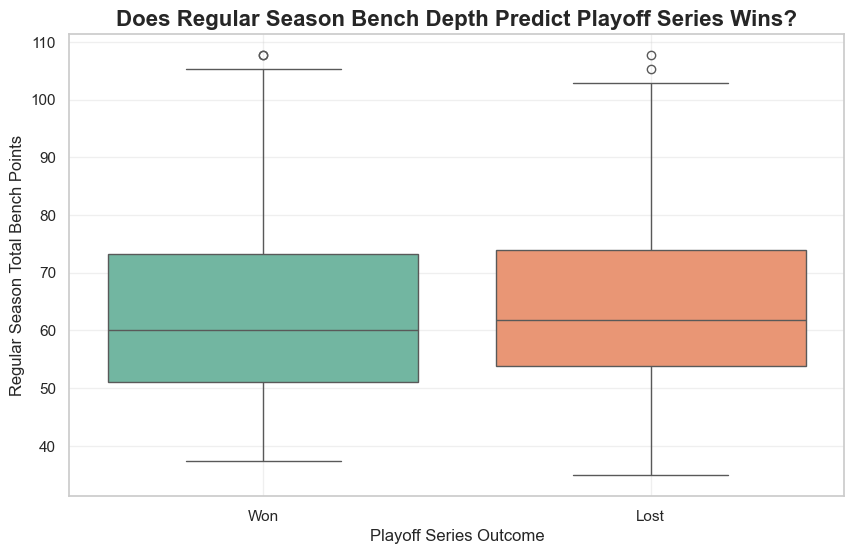


   🧪 FINAL HYPOTHESIS TEST RESULTS
Count of Winners Analyzed: 240
Count of Losers Analyzed:  240
------------------------------
Mean Bench Points (Winners): 64.06
Mean Bench Points (Losers):  64.46
------------------------------
T-Statistic: -0.2739
P-Value:     7.8431e-01
------------------------------
❌ RESULT: FAIL TO REJECT the Null Hypothesis.
CONCLUSION: No significant difference found.
Regular season bench scoring does not appear to predict playoff series outcomes.


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

# ==========================================
# 1. LOAD DATA
# ==========================================
try:
    # Load the processed data containing Playoff Series Results + Regular Season Bench Stats
    df = pd.read_csv('../data/processed/playoff_bench_analysis.csv')
    print(f"✅ Data Loaded Successfully: {len(df)} series participants found.")
    print(f"   (Represents {len(df)//2} unique playoff series from 2010-2024)")
except FileNotFoundError:
    print("❌ Error: Could not find the data file. Please run 'src/data_processing.py' first.")

# ==========================================
# 2. VISUALIZATION (EDA)
# ==========================================
# Set visual style
sns.set_theme(style="whitegrid")

# Create a Box Plot to compare distributions
plt.figure(figsize=(10, 6))
sns.boxplot(
    x='Series_Result', 
    y='Bench_Total_PTS', 
    data=df, 
    palette="Set2", 
    order=['Won', 'Lost']
)

# Add titles and labels
plt.title('Does Regular Season Bench Depth Predict Playoff Series Wins?', fontsize=16, fontweight='bold')
plt.ylabel('Regular Season Total Bench Points', fontsize=12)
plt.xlabel('Playoff Series Outcome', fontsize=12)
plt.grid(True, alpha=0.3)

# Show the plot
plt.show()

# ==========================================
# 3. STATISTICAL HYPOTHESIS TEST
# ==========================================
# Research Question: Do teams that win playoff series have significantly different 
# regular season bench scoring than teams that lose?

# Null Hypothesis (H0): Mean Bench Points (Winners) = Mean Bench Points (Losers)
# Alt Hypothesis (H1): Mean Bench Points (Winners) ≠ Mean Bench Points (Losers)

# Split the data into two groups
winners = df[df['Series_Result'] == 'Won']['Bench_Total_PTS']
losers = df[df['Series_Result'] == 'Lost']['Bench_Total_PTS']

# Perform Independent T-Test
t_stat, p_val = stats.ttest_ind(winners, losers, equal_var=False) # Welch's t-test

# ==========================================
# 4. PRINT FINAL RESULTS
# ==========================================
print("\n" + "="*50)
print("   🧪 FINAL HYPOTHESIS TEST RESULTS")
print("="*50)
print(f"Count of Winners Analyzed: {len(winners)}")
print(f"Count of Losers Analyzed:  {len(losers)}")
print("-" * 30)
print(f"Mean Bench Points (Winners): {winners.mean():.2f}")
print(f"Mean Bench Points (Losers):  {losers.mean():.2f}")
print("-" * 30)
print(f"T-Statistic: {t_stat:.4f}")
print(f"P-Value:     {p_val:.4e}")  # Scientific notation for precision

# Interpretation Logic
alpha = 0.05
print("-" * 30)
if p_val < alpha:
    print("✅ RESULT: REJECT the Null Hypothesis.")
    print("CONCLUSION: There is a statistically significant difference.")
    print("Teams with deeper benches in the regular season are more likely to win in the playoffs.")
else:
    print("❌ RESULT: FAIL TO REJECT the Null Hypothesis.")
    print("CONCLUSION: No significant difference found.")
    print("Regular season bench scoring does not appear to predict playoff series outcomes.")

🧪 Analyzing 225 Playoff Series (2010-2025)


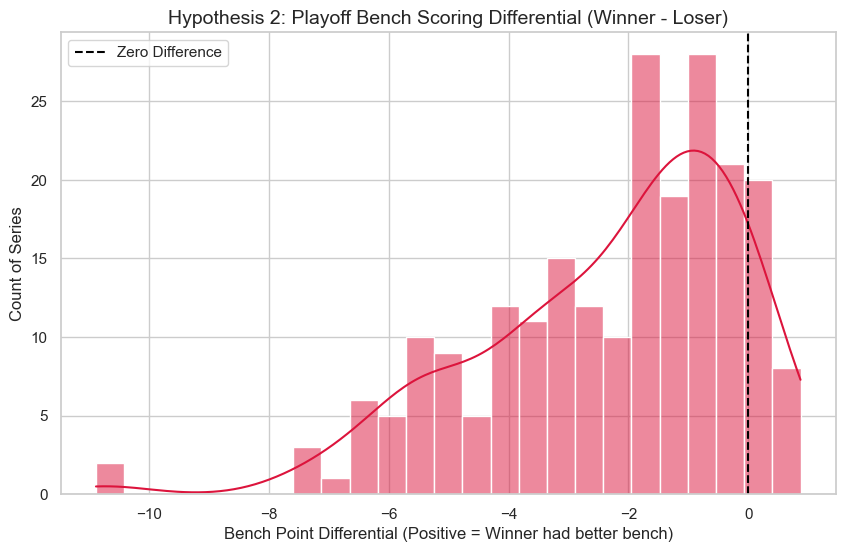

   HYPOTHESIS 2 RESULTS (ACTUAL PLAYOFF STATS)
Mean Winner Bench PPG: 2.06
Mean Loser Bench PPG:  4.39
Mean Differential:     -2.33
------------------------------
T-Statistic: -16.0910
P-Value:     3.1167e-39

✅ REJECT Null Hypothesis.
There IS a significant difference.
CONCLUSION: Series Winners typically have LOWER scoring benches (Star-heavy teams win!).


In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

# 1. Load the specific data for Hypothesis 2
try:
    df = pd.read_csv('../data/processed/hypothesis_2_data.csv')
    print(f"🧪 Analyzing {len(df)} Playoff Series (2010-2025)")
except FileNotFoundError:
    print("Error: File not found. Run process_hypothesis_2.py first.")

# 2. Visualization
plt.figure(figsize=(10, 6))
# Histogram of the difference
sns.histplot(df['Bench_Differential'], kde=True, bins=25, color='crimson')
plt.axvline(0, color='black', linestyle='--', label='Zero Difference')
plt.title('Hypothesis 2: Playoff Bench Scoring Differential (Winner - Loser)', fontsize=14)
plt.xlabel('Bench Point Differential (Positive = Winner had better bench)')
plt.ylabel('Count of Series')
plt.legend()
plt.show()

# 3. Statistical Test (One-Sample T-Test)
# H0: The mean bench differential is 0.
# H1: The mean bench differential is NOT 0.

t_stat, p_val = stats.ttest_1samp(df['Bench_Differential'], 0)

print("="*50)
print("   HYPOTHESIS 2 RESULTS (ACTUAL PLAYOFF STATS)")
print("="*50)
print(f"Mean Winner Bench PPG: {df['Winner_Bench_PPG'].mean():.2f}")
print(f"Mean Loser Bench PPG:  {df['Loser_Bench_PPG'].mean():.2f}")
print(f"Mean Differential:     {df['Bench_Differential'].mean():.2f}")
print("-" * 30)
print(f"T-Statistic: {t_stat:.4f}")
print(f"P-Value:     {p_val:.4e}")

if p_val < 0.05:
    print("\n✅ REJECT Null Hypothesis.")
    print("There IS a significant difference.")
    if df['Bench_Differential'].mean() > 0:
        print("CONCLUSION: Series Winners typically have HIGHER scoring benches.")
    else:
        print("CONCLUSION: Series Winners typically have LOWER scoring benches (Star-heavy teams win!).")
else:
    print("\n❌ FAIL TO REJECT Null Hypothesis.")
    print("CONCLUSION: Bench scoring differential is statistically zero.")
    print("Having a better bench in the playoffs does not correlate with winning the series.")

🧪 Analyzing Efficiency of 225 Playoff Series


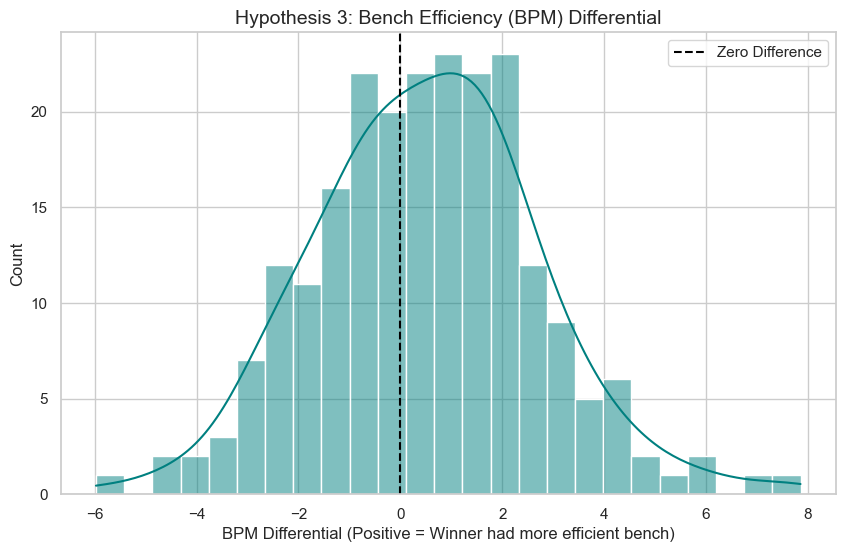

   HYPOTHESIS 3 RESULTS (EFFICIENCY/BPM)
Mean Winner Bench BPM: -0.30
Mean Loser Bench BPM:  -0.82
Mean Differential:     0.52
------------------------------
P-Value: 4.4786e-04

✅ REJECT Null Hypothesis.
Significant Difference Found.
CONCLUSION: Winners have MORE efficient benches (Quality matters!).


In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

# 1. Load Data
try:
    df = pd.read_csv('../data/processed/hypothesis_3_data.csv')
    print(f"🧪 Analyzing Efficiency of {len(df)} Playoff Series")
except FileNotFoundError:
    print("Error: File not found.")

# 2. Viz
plt.figure(figsize=(10, 6))
sns.histplot(df['Efficiency_Diff'], kde=True, bins=25, color='teal')
plt.axvline(0, color='black', linestyle='--', label='Zero Difference')
plt.title('Hypothesis 3: Bench Efficiency (BPM) Differential', fontsize=14)
plt.xlabel('BPM Differential (Positive = Winner had more efficient bench)')
plt.legend()
plt.show()

# 3. Test
# H0: Mean Efficiency Diff = 0
t_stat, p_val = stats.ttest_1samp(df['Efficiency_Diff'], 0)

print("="*50)
print("   HYPOTHESIS 3 RESULTS (EFFICIENCY/BPM)")
print("="*50)
print(f"Mean Winner Bench BPM: {df['Winner_Bench_BPM'].mean():.2f}")
print(f"Mean Loser Bench BPM:  {df['Loser_Bench_BPM'].mean():.2f}")
print(f"Mean Differential:     {df['Efficiency_Diff'].mean():.2f}")
print("-" * 30)
print(f"P-Value: {p_val:.4e}")

if p_val < 0.05:
    print("\n✅ REJECT Null Hypothesis.")
    print("Significant Difference Found.")
    if df['Efficiency_Diff'].mean() > 0:
        print("CONCLUSION: Winners have MORE efficient benches (Quality matters!).")
    else:
        print("CONCLUSION: Winners have LESS efficient benches.")
else:
    print("\n❌ FAIL TO REJECT Null Hypothesis.")
    print("CONCLUSION: No significant difference in bench efficiency.")

🧪 Analyzing VORP of 225 Playoff Series


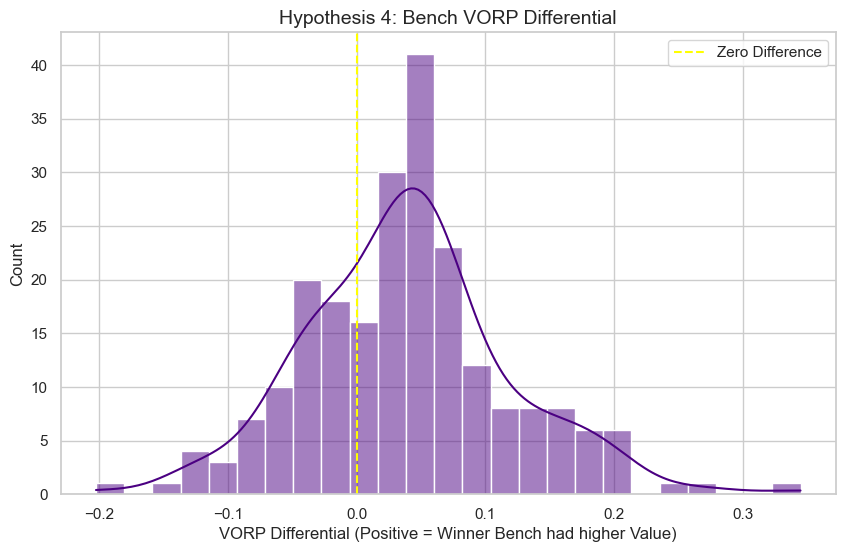

   HYPOTHESIS 4 RESULTS (VORP)
Mean Winner Bench VORP: 0.0767
Mean Loser Bench VORP:  0.0373
Mean Differential:      0.0393
------------------------------
P-Value: 2.8350e-12

✅ REJECT Null Hypothesis.
CONCLUSION: Winners have HIGHER Value benches.


In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

# 1. Load Data
try:
    df = pd.read_csv('../data/processed/hypothesis_4_data.csv')
    print(f"🧪 Analyzing VORP of {len(df)} Playoff Series")
except FileNotFoundError:
    print("Error: File not found.")

# 2. Viz
plt.figure(figsize=(10, 6))
sns.histplot(df['VORP_Diff'], kde=True, bins=25, color='indigo')
plt.axvline(0, color='yellow', linestyle='--', label='Zero Difference')
plt.title('Hypothesis 4: Bench VORP Differential', fontsize=14)
plt.xlabel('VORP Differential (Positive = Winner Bench had higher Value)')
plt.legend()
plt.show()

# 3. Test
# H0: Mean VORP Diff = 0
t_stat, p_val = stats.ttest_1samp(df['VORP_Diff'], 0)

print("="*50)
print("   HYPOTHESIS 4 RESULTS (VORP)")
print("="*50)
print(f"Mean Winner Bench VORP: {df['Winner_Bench_VORP'].mean():.4f}")
print(f"Mean Loser Bench VORP:  {df['Loser_Bench_VORP'].mean():.4f}")
print(f"Mean Differential:      {df['VORP_Diff'].mean():.4f}")
print("-" * 30)
print(f"P-Value: {p_val:.4e}")

if p_val < 0.05:
    print("\n✅ REJECT Null Hypothesis.")
    if df['VORP_Diff'].mean() > 0:
        print("CONCLUSION: Winners have HIGHER Value benches.")
    else:
        print("CONCLUSION: Winners have LOWER Value benches.")
else:
    print("\n❌ FAIL TO REJECT Null Hypothesis.")
    print("CONCLUSION: No significant difference in Bench VORP.")